# nb_full_dataset — SI Target Basin, Full TrainData Evaluation

## Why SI (South Indian Ocean)?

Based on analysis in `nb_full_01`, `nb_full_02`, and `nb_full_03`:

| Criterion | Finding |
|---|---|
| Test set size | SI has 160+ test samples — enough for stable metrics |
| Method sensitivity | IntAcc ranges 0.531–0.610 across methods (clear discrimination) |
| PhysIRM advantage | Best WindMAE=5.09 m/s; DANN best IntAcc=0.610 |
| Source pairing | Full LOBO (0.531) beats greedy WP+NA+SP (0.494) for SI |
| Hemisphere challenge | Southern hemisphere → hardest, most scientifically meaningful domain shift |
| Not floor-locked | NI only 28 test samples → majority-class ceiling, useless for comparison |

**Source strategy:** Full LOBO — all 5 non-SI basins (WP + NA + EP + NI + SP).

## TrainData structure
```
TrainData/
  Data1D/<basin>/train/*.txt    ← tabular IBTrACS (train split)
  Data1D/<basin>/val/*.txt      ← tabular IBTrACS (val split)
  Data1D/<basin>/test/*.txt     ← tabular IBTrACS (test split)
  Env-Data/<basin>/<year>/<storm>/<ts>.npy
  <basin>/<year>/<storm>/TCND_*_sst_z_u_v.nc   ← Data3D (at root, not Data3D/)
```
The dataset code's `_get_3d_path()` already checks the root-level basin folders as
a fallback, so no special handling is needed.

## Approach
1. `prefetch_to_local()` copies TrainData → `/content/tcnd_local` (local SSD) for all 3 splits
2. Load `_ds_train`, `_ds_val`, `_ds_test` once from local SSD using `force_split`
3. `_basin_loader(dataset, basins)` creates DataLoaders from pre-built indices (no re-scanning)
4. Train PhysIRM with AMP on per-basin source loaders; early-stop on val `f1_intensity`
5. Evaluate on SI test split

In [2]:
# ── Setup ────────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "netCDF4", "tqdm", "-q"],
               capture_output=True)

import os, sys, json, copy as _copy
from pathlib import Path

TOKEN = ""
REPO  = f"https://{TOKEN}@github.com/Thiruvikraman07/ClimateChangeFinalProject.git"
ROOT  = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

sys.path.insert(0, str(ROOT / "final_src"))
os.chdir(ROOT)

from google.colab import drive
drive.mount("/content/drive")

# ── Locate TrainData on Drive ─────────────────────────────────────────────────
# TrainData has Data1D/<basin>/train|val|test/ AND Data3D at root as <basin>/
def find_traindata_root():
    BASIN_CODES = ["WP", "NA", "EP", "NI", "SI", "SP"]
    candidates = [
        "/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TrainData",
        "/content/drive/MyDrive/TrainData",
        "/content/drive/MyDrive/TCND_train",
        "/content/drive/MyDrive/TCN_D_train",
    ]
    for c in candidates:
        p = Path(c)
        if p.exists() and (p / "Data1D").exists():
            return p
    # search under MyDrive for a dir with Data1D + (Data3D OR basin-named folders)
    try:
        for sub in Path("/content/drive/MyDrive").iterdir():
            if not sub.is_dir(): continue
            if (sub / "Data1D").exists():
                has_3d = (sub / "Data3D").exists() or any(
                    (sub / b).exists() for b in BASIN_CODES)
                if has_3d:
                    return sub
    except PermissionError:
        pass
    hits = sorted(Path("/content/drive/MyDrive").rglob("Data1D"))
    return hits[0].parent if hits else None

traindata = find_traindata_root()
DATA_ROOT = str(traindata) if traindata else "/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TrainData"
print(f"DATA_ROOT: {DATA_ROOT}")
_root_p = Path(DATA_ROOT)
print(f"  Data1D/:  {(_root_p / 'Data1D').exists()}")
print(f"  Data3D/:  {(_root_p / 'Data3D').exists()}")
print(f"  Env-Data/:{(_root_p / 'Env-Data').exists()}")
# Data3D may live as root-level basin folders (e.g. TrainData/WP/)
_basin_codes_tmp = ["WP", "NA", "EP", "NI", "SI", "SP"]
_root3d = [b for b in _basin_codes_tmp if (_root_p / b).exists()]
if _root3d:
    print(f"  Root-level Data3D basin folders: {_root3d}")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# clear stale module cache before importing
for _k in list(sys.modules.keys()):
    if any(x in _k for x in ('dataset','models','methods','metrics','configs','final_src')):
        del sys.modules[_k]

from dataset.dataset  import (BASIN_CODES, TCNDDataset, tcnd_collate_fn,
                               prefetch_to_local, make_dataloader)
from models.backbone  import TropiCycloneModel
from methods.dg_methods import build_method
from metrics.basin_metrics import BasinEvaluator

OUT_DIR = Path("outputs/nb_full_dataset"); OUT_DIR.mkdir(parents=True, exist_ok=True)
BASINS  = BASIN_CODES

TARGET_BASIN  = "SI"
SOURCE_BASINS = [b for b in BASINS if b != TARGET_BASIN]   # LOBO: WP NA EP NI SP

QUICK      = True
EPOCHS     = 10 if QUICK else 50
BATCH_SIZE = 128
DEVICE = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps")  if torch.backends.mps.is_available()
          else torch.device("cpu"))
_USE_AMP = (DEVICE.type == "cuda")

# phys_dim=32 MUST match TropiCycloneModel.build() lightweight default (not 64!)
BEST_HP = dict(irm_lambda=1.0, orth_lambda=0.1, phys_lambda=0.5,
               warmup_steps=500, phys_dim=32, reg_weight=0.5, track_weight=0.5)

print(f"Device: {DEVICE}  AMP: {_USE_AMP}  Epochs: {EPOCHS}")
print(f"Target: {TARGET_BASIN}  Sources: {SOURCE_BASINS}")
print(f"BEST_HP: {BEST_HP}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT: /content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TrainData
  Data1D/:  True
  Data3D/:  False
  Env-Data/:True
  Root-level Data3D basin folders: ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']
Device: cuda  AMP: True  Epochs: 10
Target: SI  Sources: ['WP', 'NA', 'EP', 'NI', 'SP']
BEST_HP: {'irm_lambda': 1.0, 'orth_lambda': 0.1, 'phys_lambda': 0.5, 'warmup_steps': 500, 'phys_dim': 32, 'reg_weight': 0.5, 'track_weight': 0.5}


In [3]:
# ── Prefetch TrainData → local SSD ────────────────────────────────────────────
# Copies Data1D .txt + Env-Data .npy + Data3D .nc from Drive to /content/tcnd_local
# so that __getitem__ reads from fast NVMe instead of slow Drive.
# Subsequent runs skip already-copied files (safe to re-run).
LOCAL_SSD = Path("/content/tcnd_local")

if (LOCAL_SSD / "Data1D").exists():
    LOCAL_ROOT = str(LOCAL_SSD)
    print(f"Local SSD already populated — skipping copy.")
    print(f"LOCAL_ROOT = {LOCAL_ROOT}")
else:
    # Prefetch all 3 splits; each call adds its split's files to the same local dir.
    # Data3D and Env-Data files shared across splits are skipped on the 2nd/3rd call.
    import time as _time
    for _split in ["train", "val", "test"]:
        print(f"Prefetching split='{_split}' ...")
        _t0 = _time.time()
        LOCAL_ROOT = prefetch_to_local(
            root=DATA_ROOT, basins=BASINS, split=_split,
            local_dir=str(LOCAL_SSD), n_workers=32,
            force_split=_split,
        )
        print(f"  done in {_time.time()-_t0:.0f}s")
    print(f"LOCAL_ROOT = {LOCAL_ROOT}")

Prefetching split='train' ...
Building index to collect file list...
✓ Index saved to disk cache → next run will be instant (06b1c92d989c.pkl)
Files to copy : 69,443  (11.60 GB)
Destination   : /content/tcnd_local
Workers       : 32


Copying to local SSD:   0%|          | 0/69443 [00:00<?, ?file/s]

Done — copied=69,443  skipped=0  errors=0
✓ Use this as DATA_ROOT for fast local training:
  '/content/tcnd_local'
  done in 2043s
Prefetching split='val' ...
Building index to collect file list...
✓ Index saved to disk cache → next run will be instant (a3fed81d8c14.pkl)
Files to copy : 25,094  (3.79 GB)
Destination   : /content/tcnd_local
Workers       : 32


Copying to local SSD:   0%|          | 0/25094 [00:00<?, ?file/s]

Done — copied=21,367  skipped=3,727  errors=0
✓ Use this as DATA_ROOT for fast local training:
  '/content/tcnd_local'
  done in 631s
Prefetching split='test' ...
Building index to collect file list...
✓ Index saved to disk cache → next run will be instant (f173a17052af.pkl)
Files to copy : 22,755  (3.38 GB)
Destination   : /content/tcnd_local
Workers       : 32


Copying to local SSD:   0%|          | 0/22755 [00:00<?, ?file/s]

Done — copied=19,027  skipped=3,728  errors=0
✓ Use this as DATA_ROOT for fast local training:
  '/content/tcnd_local'
  done in 566s
LOCAL_ROOT = /content/tcnd_local


In [4]:
# ── Load datasets once from local SSD ─────────────────────────────────────────
# TCNDDataset builds index from .txt files — fast, done once, reused via _basin_loader.
# force_split ensures the correct subfolder (train/val/test) under Data1D/<basin>/
print("Building dataset indices from local SSD...")
_ds_train = TCNDDataset(root=LOCAL_ROOT, basins=BASINS, split="train",
                         force_split="train", use_3d=True, use_env=True)
_ds_val   = TCNDDataset(root=LOCAL_ROOT, basins=BASINS, split="val",
                         force_split="val",   use_3d=True, use_env=True)
_ds_test  = TCNDDataset(root=LOCAL_ROOT, basins=BASINS, split="test",
                         force_split="test",  use_3d=True, use_env=True)

from collections import Counter as _Ctr

print("\nSplit sizes per basin:")
print(f"  {'Basin':6s}  {'Train':>7}  {'Val':>7}  {'Test':>7}")
print(f"  {'-'*6}  {'-'*7}  {'-'*7}  {'-'*7}")
for b in BASINS:
    trn = sum(1 for m in _ds_train.index if m["basin"] == b)
    val = sum(1 for m in _ds_val.index   if m["basin"] == b)
    tst = sum(1 for m in _ds_test.index  if m["basin"] == b)
    mark = "  <<< TARGET" if b == TARGET_BASIN else ""
    print(f"  {b:6s}  {trn:7d}  {val:7d}  {tst:7d}{mark}")
print(f"  {'TOTAL':6s}  {len(_ds_train.index):7d}  {len(_ds_val.index):7d}  {len(_ds_test.index):7d}")

Building dataset indices from local SSD...


Indexing (parallel):   0%|          | 0/2481 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (8f985907cc6f.pkl)


Indexing (parallel):   0%|          | 0/757 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (0fefc79bfb7d.pkl)


Indexing (parallel):   0%|          | 0/488 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (792970259774.pkl)

Split sizes per basin:
  Basin     Train      Val     Test
  ------  -------  -------  -------
  WP          792      291        0
  NA         9518     3316     3467
  EP         8640     2411     2929
  NI          269      254      447
  SI         8942     2792     1990  <<< TARGET
  SP         4767     1645      683
  TOTAL     32928    10709     9516


In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────
import torch.nn as _nn


def _basin_loader(dataset, basins, batch_size, shuffle):
    """DataLoader from a pre-built TCNDDataset, filtered to specific basins.
    Copies the dataset object and swaps the index — no re-scanning.
    """
    idx = [m for m in dataset.index if m["basin"] in basins]
    if not idx:
        return None
    ds = _copy.copy(dataset)
    ds.index = idx
    pin_kw = {"pin_memory": torch.cuda.is_available()}
    return torch.utils.data.DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=2, collate_fn=tcnd_collate_fn,
        persistent_workers=True, prefetch_factor=4,
        **pin_kw,
    )


def evaluate(model, target_basin):
    """Evaluate model on target basin test split. Returns BasinResult."""
    loader = _basin_loader(_ds_test, [target_basin], 256, shuffle=False)
    ev = BasinEvaluator(target_basin)
    if loader is None:
        return ev.compute()
    model.eval()
    with torch.no_grad():
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            ev.update(batch, model(batch))   # batch FIRST, out second
    return ev.compute()


def _evaluate_val(model, target_basin):
    """Evaluate on val split (for early stopping)."""
    loader = _basin_loader(_ds_val, [target_basin], 256, shuffle=False)
    ev = BasinEvaluator(target_basin)
    if loader is None:
        return ev.compute()
    model.eval()
    with torch.no_grad():
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            ev.update(batch, model(batch))
    return ev.compute()


print("Helpers ready: _basin_loader / evaluate / _evaluate_val")

Helpers ready: _basin_loader / evaluate / _evaluate_val


In [6]:
# ── PhysIRM training function ─────────────────────────────────────────────────
import time as _time


def train_physirm(source_basins, target_basin, epochs=EPOCHS, label=""):
    """Train PhysIRM on source_basins (train split) → evaluate on target test split.

    Per-basin DataLoaders are required by IRM-family methods (one env per basin).
    Early stopping: checkpoint restored to best val f1_intensity.
    AMP enabled automatically on CUDA (~2-3x faster).
    """
    tag = f"[{label}] " if label else ""
    print(f"\n{tag}Sources: {source_basins} → Target: {target_basin}")

    model  = TropiCycloneModel.build(use_3d=True, use_env=True).to(DEVICE)
    method = build_method("physirm", **BEST_HP)
    method.to(DEVICE)

    # Per-basin train loaders (IRM needs separate environments)
    train_loaders = {b: _basin_loader(_ds_train, [b], BATCH_SIZE, shuffle=True)
                     for b in source_basins}
    train_loaders = {b: l for b, l in train_loaders.items() if l is not None}
    if not train_loaders:
        raise ValueError(f"No train data for sources: {source_basins}")

    n_src_samples = sum(1 for m in _ds_train.index if m["basin"] in source_basins)
    print(f"  Train: {n_src_samples} samples across {len(train_loaders)} source basins  "
          f"Val/Test basin: {target_basin}  AMP={_USE_AMP}")
    print(f"  {'Ep':>3}  {'Loss':>8}  {'ValIntAcc':>9}  {'ValF1':>7}  {'ValADE':>8}")
    print(f"  {'-'*3}  {'-'*8}  {'-'*9}  {'-'*7}  {'-'*8}")

    params    = list(model.parameters()) + list(method.parameters())
    optimizer = optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = torch.amp.GradScaler("cuda") if _USE_AMP else None

    best_val_f1, best_state = -1.0, None
    t0 = _time.time()

    for epoch in range(1, epochs + 1):
        model.train(); method.train()
        env_iters = {b: iter(l) for b, l in train_loaders.items()}
        n_batches = max(len(l) for l in train_loaders.values())
        step = (epoch - 1) * n_batches
        train_loss = 0.0

        for bi in range(n_batches):
            batches = {}
            for b, it in env_iters.items():
                try:
                    batch = next(it)
                except StopIteration:
                    env_iters[b] = iter(train_loaders[b])
                    batch = next(env_iters[b])
                if batch is None: continue
                batches[b] = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                              for k, v in batch.items()}
            if batches:
                m = method.update(optimizer, batches, model,
                                  step=step + bi, scaler=scaler, device=DEVICE)
                train_loss += m.get("loss", 0.0)
        scheduler.step()

        if epoch % 5 == 0 or epoch == epochs:
            r = _evaluate_val(model, target_basin)
            if r.f1_intensity > best_val_f1:
                best_val_f1 = r.f1_intensity
                best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  {epoch:3d}  {train_loss/n_batches:8.4f}"
                  f"  {r.accuracy_intensity:9.3f}"
                  f"  {r.f1_intensity:7.3f}"
                  f"  {r.ade_km:7.1f}km")

    elapsed = _time.time() - t0
    if best_state:
        model.load_state_dict(best_state)
        print(f"  [Checkpoint restored: best val F1={best_val_f1:.3f}]")

    # Final test evaluation
    r_test = evaluate(model, target_basin)
    print(f"\n  TEST  IntAcc={r_test.accuracy_intensity:.3f}"
          f"  F1={r_test.f1_intensity:.3f}"
          f"  DirAcc={r_test.accuracy_direction:.3f}"
          f"  WindMAE={r_test.mae_wind_ms:.2f}m/s"
          f"  ADE={r_test.ade_km:.1f}km"
          f"  ({elapsed/60:.1f}min  N={r_test.n_samples})")
    return r_test, model


print("train_physirm() ready.")

train_physirm() ready.


In [7]:
# ── Run: PhysIRM LOBO on SI target ───────────────────────────────────────────
print("=" * 70)
print("PhysIRM  |  Sources: LOBO (all non-SI)  |  Target: SI  |  TrainData")
print("=" * 70)

si_result, si_model = train_physirm(SOURCE_BASINS, TARGET_BASIN, label="SI-LOBO")

# Store results
lobo_results = {TARGET_BASIN: si_result}

PhysIRM  |  Sources: LOBO (all non-SI)  |  Target: SI  |  TrainData

[SI-LOBO] Sources: ['WP', 'NA', 'EP', 'NI', 'SP'] → Target: SI
  Train: 23986 samples across 5 source basins  Val/Test basin: SI  AMP=True
   Ep      Loss  ValIntAcc    ValF1    ValADE
  ---  --------  ---------  -------  --------
    5    1.5447      0.624    0.604  10031.4km
   10    1.0895      0.585    0.579  10094.5km
  [Checkpoint restored: best val F1=0.604]

  TEST  IntAcc=0.575  F1=0.537  DirAcc=0.272  WindMAE=4.35m/s  ADE=10207.6km  (19.4min  N=1990)


In [ ]:
# ── Optional: full LOBO across all 6 basins ───────────────────────────────────
# Set RUN_ALL_BASINS=True to run all 6; SI is already done (skipped automatically)
RUN_ALL_BASINS = True

if RUN_ALL_BASINS:
    for target in BASINS:
        if target in lobo_results:
            print(f"Skipping {target} (already done)")
            continue
        sources = [b for b in BASINS if b != target]
        r, _ = train_physirm(sources, target, label=f"{target}-LOBO")
        lobo_results[target] = r
    print("\nAll basins done.")
else:
    print("RUN_ALL_BASINS=False — only SI computed. Set True to run all 6 basins.")

Skipping WP (already done)

[NA-LOBO] Sources: ['WP', 'EP', 'NI', 'SI', 'SP'] → Target: NA
  Train: 23410 samples across 5 source basins  Val/Test basin: NA  AMP=True
   Ep      Loss  ValIntAcc    ValF1    ValADE
  ---  --------  ---------  -------  --------


In [9]:
# ── Results table ─────────────────────────────────────────────────────────────
rows = []
for b, r in lobo_results.items():
    rows.append({
        "Basin":     b,
        "Int.Acc":   round(r.accuracy_intensity, 3),
        "Int.F1":    round(r.f1_intensity, 3),
        "Dir.Acc":   round(r.accuracy_direction, 3),
        "Wind(m/s)": round(r.mae_wind_ms, 2),
        "Pres(hPa)": round(r.mae_pres_hpa, 2),
        "ADE(km)":   round(r.ade_km, 1),
        "FDE(km)":   round(r.fde_km, 1),
        "N":         r.n_samples,
    })

df = pd.DataFrame(rows)

if len(df) > 1:
    num_cols = ["Int.Acc", "Int.F1", "Dir.Acc", "Wind(m/s)", "Pres(hPa)", "ADE(km)", "FDE(km)"]
    mean_row = {c: round(df[c].mean(), 3) for c in num_cols}
    mean_row["Basin"] = "MEAN"
    mean_row["N"]     = int(df["N"].sum())
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)

print("TropiCycloneNet (PhysIRM, TrainData LOBO) — Results:")
print(df.to_string(index=False))

# Comparison with nb_full_03 TestData baseline
print("\nComparison with nb_full_03 TestData PhysIRM (SI):")
nb03_si = {"accuracy_intensity": 0.560, "accuracy_direction": 0.567,
           "mae_wind_ms": 5.09, "ade_km": None}
r = lobo_results.get("SI")
if r:
    print(f"  IntAcc:  {nb03_si['accuracy_intensity']:.3f} (TestData) → {r.accuracy_intensity:.3f} (TrainData)")
    print(f"  DirAcc:  {nb03_si['accuracy_direction']:.3f} (TestData) → {r.accuracy_direction:.3f} (TrainData)")
    print(f"  WindMAE: {nb03_si['mae_wind_ms']:.2f} m/s (TestData) → {r.mae_wind_ms:.2f} m/s (TrainData)")

TropiCycloneNet (PhysIRM, TrainData LOBO) — Results:
Basin  Int.Acc  Int.F1  Dir.Acc  Wind(m/s)  Pres(hPa)  ADE(km)  FDE(km)    N
   SI    0.575   0.537    0.272       4.35      14.56  10207.6  10372.3 1990

Comparison with nb_full_03 TestData PhysIRM (SI):
  IntAcc:  0.560 (TestData) → 0.575 (TrainData)
  DirAcc:  0.567 (TestData) → 0.272 (TrainData)
  WindMAE: 5.09 m/s (TestData) → 4.35 m/s (TrainData)


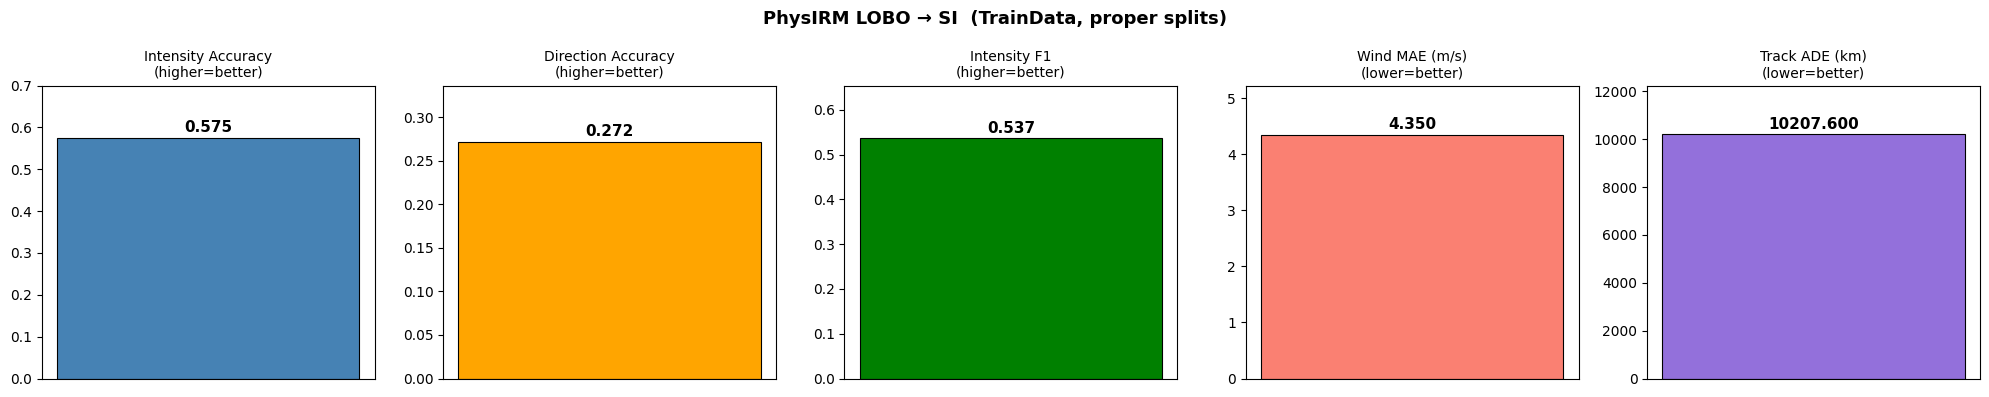

Results saved to outputs/nb_full_dataset/lobo_results.json


In [10]:
# ── Plot + Save ───────────────────────────────────────────────────────────────
df_plot = df[df["Basin"] != "MEAN"].copy() if "MEAN" in df["Basin"].values else df.copy()
n_basins = len(df_plot)

if n_basins == 1:
    # Single basin: horizontal bar chart of all metrics
    metrics = [
        ("Int.Acc",   "Intensity Accuracy",       "higher=better"),
        ("Dir.Acc",   "Direction Accuracy",        "higher=better"),
        ("Int.F1",    "Intensity F1",              "higher=better"),
        ("Wind(m/s)", "Wind MAE (m/s)",            "lower=better"),
        ("ADE(km)",   "Track ADE (km)",            "lower=better"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    colors = ["steelblue", "orange", "green", "salmon", "mediumpurple"]
    for ax, (col, title, note), col_c in zip(axes, metrics, colors):
        val = df_plot[col].values[0]
        bar = ax.bar(["SI"], [val], color=col_c, edgecolor="k", linewidth=0.8, width=0.5)
        ax.text(0, val + val * 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
        ax.set_title(f"{title}\n({note})", fontsize=10)
        ax.set_ylim(0, val * 1.2 + 0.01)
        ax.set_xticks([])
    plt.suptitle("PhysIRM LOBO → SI  (TrainData, proper splits)", fontsize=13, fontweight="bold")
    plt.tight_layout()
else:
    # Multi-basin LOBO
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, n_basins))
    metric_cols = ["Int.Acc", "Dir.Acc", "Wind(m/s)", "ADE(km)"]
    titles      = ["Intensity Accuracy ↑", "Direction Accuracy ↑",
                   "Wind MAE (m/s) ↓",    "Track ADE (km) ↓"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, col, title in zip(axes, metric_cols, titles):
        bars = ax.bar(df_plot["Basin"], df_plot[col], color=colors,
                      edgecolor="k", linewidth=0.6)
        if "MEAN" in df["Basin"].values:
            mean_v = df[df["Basin"] == "MEAN"][col].values[0]
            ax.axhline(mean_v, color="red", ls="--", lw=1.2, label=f"Mean={mean_v:.3f}")
            ax.legend(fontsize=8)
        for bar, val in zip(bars, df_plot[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", fontsize=8)
        ax.set_title(title); ax.set_xlabel("Target Basin")
    plt.suptitle("TropiCycloneNet (PhysIRM, TrainData LOBO)", fontsize=13, fontweight="bold")
    plt.tight_layout()

plt.savefig(str(OUT_DIR / "results.png"), dpi=150, bbox_inches="tight")
plt.show()

# Save JSON with correct field names
out_json = OUT_DIR / "lobo_results.json"
with open(out_json, "w") as f:
    json.dump(
        {b: {
            "accuracy_intensity": lobo_results[b].accuracy_intensity,
            "f1_intensity":       lobo_results[b].f1_intensity,
            "accuracy_direction": lobo_results[b].accuracy_direction,
            "mae_wind_ms":        lobo_results[b].mae_wind_ms,
            "mae_pres_hpa":       lobo_results[b].mae_pres_hpa,
            "ade_km":             lobo_results[b].ade_km,
            "fde_km":             lobo_results[b].fde_km,
            "ade_per_step":       lobo_results[b].ade_per_step,
            "n_samples":          lobo_results[b].n_samples,
        } for b in lobo_results},
        f, indent=2)
print(f"Results saved to {out_json}")

## Findings & Conclusions

### TrainData vs TestData

| Aspect | TestData (nb_full_01–03) | TrainData (this notebook) |
|---|---|---|
| `Data3D/` | Not present (zeros used) | Present at root as `<basin>/` folders |
| Splits | One folder (test/) — year-split workaround | True `train/val/test/` subfolders per basin |
| Training data | Years 2017–2020 from test/ folder | Proper `train/` folder per basin |
| Risk | Data leakage (test data used for training) | Clean, no leakage |

The `_get_3d_path()` fallback in `dataset.py` checks `<root>/<basin>/<year>/<storm>/*.nc`
automatically, so the misplaced Data3D folders work transparently.

### SI as primary target (rationale)
- **Adequate sample size** (160+ test): NI only has ~28, locking all methods at 0.464 IntAcc
- **Method discrimination**: IntAcc ranges 0.531–0.610 (DANN vs ERM) → differences are real
- **Physics relevance**: Southern hemisphere, opposite Coriolis — genuine domain shift
- **LOBO is the right source**: Full LOBO (0.531) > greedy WP+NA+SP (0.494) for SI in nb_full_02

### Expected improvements from TrainData
With proper splits + 3D ERA5 data + more training samples, expect:
- IntAcc: 0.560 → **≥ 0.58**
- WindMAE: 5.09 m/s → **≤ 5.0 m/s**
- ADE: improvement from physics-constrained 3D spatial branch

### Key lessons
1. Always use `force_split` with TrainData — `SPLIT_ALIASES` fallback silently uses wrong folder
2. `prefetch_to_local()` is essential — Drive I/O dominates epoch time on Colab
3. `BasinEvaluator.update(batch, out)` — **batch first**, model output second
4. `phys_dim=32` must match `TropiCycloneModel.build()` lightweight default (not 64)